# Project 01 (basic) — Search algorithms: A\*, UCS, BFS, IDDFS

**Module 06 — Theory of AI 1**

In this notebook you implement and *compare* the classical search procedures
from parts 1 and 2 of the script on two concrete problems: the **Romania map**
(route planning with real km costs) and the **8-puzzle**.

The goal is not only that the algorithms run, but that you *check the theory
empirically*:
- UCS and A\* are **optimal**, BFS and greedy in general are **not**.
- A **higher admissible heuristic** (Manhattan $h_2$ instead of Hamming $h_1$)
  expands **fewer nodes** — the *dominance* from the script, made visible.

> **How you work:** run the given cells (infrastructure, BFS, best-first) in
> order. Then solve **tasks 1–3** (the cells with `TODO` /
> `NotImplementedError`). The reference solution is in the folder `solution/`.

## Setup

This project only needs the standard library and `matplotlib` (for a bar
chart). Both are already installed in the repository `venv` (see `SETUP.md`
and `requirements.txt` in the root directory).

In Jupyter/VS Code, select the kernel of the `.venv`. Then simply run the cells
from top to bottom.

In [1]:
# Only the standard library + matplotlib (for a comparison bar chart at the end).
import heapq
import itertools
from collections import deque
from dataclasses import dataclass, field
from typing import Optional, Any, Callable
import matplotlib.pyplot as plt

print("Libraries loaded.")

Libraries loaded.


## Part A — Infrastructure (given)

First the building blocks that *all* search procedures share: the **node** (a
path in the search tree), the function **`expand`** (which generates children
according to the transition model) and the abstract **`Problem`** interface.
After that the two concrete problems. Read the code — you need it for the
tasks.

In [2]:
# ---- Nodes of the search tree --------------------------------------------
@dataclass
class Node:
    """A node IS a path: it knows its state, its parent, the action that led
    here, the path cost g and the depth."""
    state: Any
    parent: "Optional[Node]" = None
    action: Any = None
    path_cost: float = 0.0      # g(n)
    depth: int = 0

def path_actions(node: Node):
    """Reconstructs the sequence of actions from the root down to node."""
    actions = []
    while node.parent is not None:
        actions.append(node.action)
        node = node.parent
    return list(reversed(actions))

def path_states(node: Node):
    """The sequence of states from the root down to node (for the cycle check)."""
    states = []
    while node is not None:
        states.append(node.state)
        node = node.parent
    return list(reversed(states))

def expand(problem, node: Node):
    """Generates all child nodes of node according to the transition model."""
    s = node.state
    for action in problem.actions(s):
        s2 = problem.result(s, action)
        cost = node.path_cost + problem.action_cost(s, action, s2)
        yield Node(s2, node, action, cost, node.depth + 1)

print("Search tree infrastructure ready.")

Search tree infrastructure ready.


In [3]:
# ---- The abstract problem interface ---------------------------------------
class Problem:
    """A search problem (S, s0, A, Result, Goal, c). Concrete problems inherit
    from this and override the methods."""
    def __init__(self, initial, goal=None):
        self.initial = initial
        self.goal = goal
    def actions(self, state):        raise NotImplementedError
    def result(self, state, action): raise NotImplementedError
    def is_goal(self, state):        return state == self.goal
    def action_cost(self, s, a, s2): return 1          # default: unit costs
    def h(self, state):              return 0          # default heuristic (uninformed)

print("Problem base class ready.")

Problem base class ready.


In [4]:
# ---- Concrete problem 1: the Romania map ----------------------------------
# An undirected graph: city -> {neighbour: road length in km}
romania_map = {
    "Arad": {"Zerind": 75, "Sibiu": 140, "Timisoara": 118},
    "Zerind": {"Arad": 75, "Oradea": 71},
    "Oradea": {"Zerind": 71, "Sibiu": 151},
    "Sibiu": {"Arad": 140, "Oradea": 151, "Fagaras": 99, "Rimnicu": 80},
    "Timisoara": {"Arad": 118, "Lugoj": 111},
    "Lugoj": {"Timisoara": 111, "Mehadia": 70},
    "Mehadia": {"Lugoj": 70, "Drobeta": 75},
    "Drobeta": {"Mehadia": 75, "Craiova": 120},
    "Craiova": {"Drobeta": 120, "Rimnicu": 146, "Pitesti": 138},
    "Rimnicu": {"Sibiu": 80, "Craiova": 146, "Pitesti": 97},
    "Fagaras": {"Sibiu": 99, "Bucharest": 211},
    "Pitesti": {"Rimnicu": 97, "Craiova": 138, "Bucharest": 101},
    "Bucharest": {"Fagaras": 211, "Pitesti": 101, "Giurgiu": 90, "Urziceni": 85},
    "Giurgiu": {"Bucharest": 90},
    "Urziceni": {"Bucharest": 85, "Hirsova": 98, "Vaslui": 142},
    "Hirsova": {"Urziceni": 98, "Eforie": 86},
    "Eforie": {"Hirsova": 86},
    "Vaslui": {"Urziceni": 142, "Iasi": 92},
    "Iasi": {"Vaslui": 92, "Neamt": 87},
    "Neamt": {"Iasi": 87},
}
# Straight-line distance to Bucharest (an admissible, consistent heuristic).
sld_to_bucharest = {
    "Arad": 366, "Bucharest": 0, "Craiova": 160, "Drobeta": 242, "Eforie": 161,
    "Fagaras": 176, "Giurgiu": 77, "Hirsova": 151, "Iasi": 226, "Lugoj": 244,
    "Mehadia": 241, "Neamt": 234, "Oradea": 380, "Pitesti": 100, "Rimnicu": 193,
    "Sibiu": 253, "Timisoara": 329, "Urziceni": 80, "Vaslui": 199, "Zerind": 374,
}

class RomaniaProblem(Problem):
    def actions(self, state):        return list(romania_map[state].keys())
    def result(self, state, action): return action          # the action = the target city
    def action_cost(self, s, a, s2): return romania_map[s][s2]
    def h(self, state):              return sld_to_bucharest[state]

romania = RomaniaProblem("Arad", "Bucharest")
print("Romania problem ready. Actions from Arad:", romania.actions("Arad"))

Romania problem ready. Actions from Arad: ['Zerind', 'Sibiu', 'Timisoara']


In [5]:
# ---- Concrete problem 2: the 8-puzzle -------------------------------------
# State = a tuple of the 9 squares, 0 = the gap. Goal: (1,2,3,4,5,6,7,8,0)
GOAL8 = (1, 2, 3, 4, 5, 6, 7, 8, 0)

class EightPuzzle(Problem):
    def __init__(self, initial, goal=GOAL8):
        super().__init__(initial, goal)
    def actions(self, state):
        i = state.index(0)          # the position of the gap (0..8)
        r, c = divmod(i, 3)
        acts = []
        if r > 0: acts.append("U")
        if r < 2: acts.append("D")
        if c > 0: acts.append("L")
        if c < 2: acts.append("R")
        return acts
    def result(self, state, action):
        i = state.index(0)
        swap = {"U": i - 3, "D": i + 3, "L": i - 1, "R": i + 1}[action]
        lst = list(state)
        lst[i], lst[swap] = lst[swap], lst[i]
        return tuple(lst)
    def action_cost(self, s, a, s2): return 1
    # --- two admissible heuristics ---
    def h1(self, state):            # misplaced tiles (Hamming), excluding the gap
        return sum(1 for i, v in enumerate(state) if v != 0 and v != self.goal[i])
    def h2(self, state):            # the sum of the Manhattan distances
        total = 0
        for i, v in enumerate(state):
            if v == 0:
                continue
            gi = self.goal.index(v)
            total += abs(i // 3 - gi // 3) + abs(i % 3 - gi % 3)
        return total
    h = h2                          # default: the stronger heuristic

def show8(state):
    return "\n".join(" ".join(str(x) if x else "_" for x in state[r*3:r*3+3]) for r in range(3))

# A solvable starting position 15 moves away (it shows the dominance clearly).
start8 = (2, 6, 3, 1, 8, 4, 7, 0, 5)
p8 = EightPuzzle(start8)
print("8-puzzle start:\n" + show8(start8))
print("h1 =", p8.h1(start8), " h2 =", p8.h2(start8))

8-puzzle start:
2 6 3
1 8 4
7 _ 5
h1 = 6  h2 = 9


## Part B — BFS as a model (given)

Breadth-first search is given completely, so that you can see the pattern: a
FIFO frontier, a `reached` set against cycles, the goal test at generation
time. **Note:** BFS minimizes the *number of steps*, not the *km* — on the map
with unequal costs BFS is therefore **not** guaranteed to be optimal.

In [6]:
# ---- Breadth-first search (BFS) — given completely as a model -------------
def breadth_first_search(problem):
    """Graph BFS. The goal test happens at GENERATION time (which saves a layer).
    FIFO queue. Returns: (the goal node or None, the number of expanded nodes)."""
    node = Node(problem.initial)
    if problem.is_goal(node.state):
        return node, 0
    frontier = deque([node])           # FIFO
    reached = {problem.initial}
    expanded = 0
    while frontier:
        node = frontier.popleft()
        expanded += 1
        for child in expand(problem, node):
            s = child.state
            if problem.is_goal(s):
                return child, expanded
            if s not in reached:
                reached.add(s)
                frontier.append(child)
    return None, expanded

goal, exp = breadth_first_search(romania)
print("BFS Arad->Bucharest:", path_states(goal))
print("Path cost:", goal.path_cost, "| expanded nodes:", exp)
print("(BFS minimizes the NUMBER of steps, not the km — so it may not be optimal!)")

BFS Arad->Bucharest: ['Arad', 'Sibiu', 'Fagaras', 'Bucharest']
Path cost: 450.0 | expanded nodes: 6
(BFS minimizes the NUMBER of steps, not the km — so it may not be optimal!)


## Part C — Generic best-first search (given)

The decisive insight of the script: **UCS, A\* and greedy differ in only one
line** — the evaluation function $f(n)$. `best_first_search` implements what
they have in common (a priority frontier on $f$, the goal test at expansion
time, replacing a more expensive path). You build the individual procedures in
a moment by plugging in the right $f$.

In [7]:
# ---- Generic best-first search — given ------------------------------------
def best_first_search(problem, f: Callable[[Node], float]):
    """Always expands the frontier node with the smallest f(n). The goal test
    happens at EXPANSION time. Replaces a frontier state when a cheaper path is
    found. Returns: (the goal node or None, the number expanded)."""
    node = Node(problem.initial)
    counter = itertools.count()        # a unique tie-breaker for the heap
    frontier = [(f(node), next(counter), node)]
    reached = {problem.initial: node}
    expanded = 0
    while frontier:
        _, _, node = heapq.heappop(frontier)
        if problem.is_goal(node.state):
            return node, expanded
        expanded += 1
        for child in expand(problem, node):
            s = child.state
            if s not in reached or child.path_cost < reached[s].path_cost:
                reached[s] = child
                heapq.heappush(frontier, (f(child), next(counter), child))
    return None, expanded

print("best_first_search ready — UCS and A* are just the right choice of f.")

best_first_search ready — UCS and A* are just the right choice of f.


### Task 1 — UCS and A\* (choosing the right $f$)

- **UCS:** $f(n) = g(n)$ — only the path cost so far.
- **A\*:** $f(n) = g(n) + h(n)$ — the cost plus the estimated remaining cost.
- **Greedy:** $f(n) = h(n)$ — only the heuristic (for comparison).

Fill in the three functions below. If they are correct, UCS and A\* both return
**418 km** for Arad → Bucharest, but A\* expands **fewer** nodes.

In [8]:
# ---- UCS and A* as special cases of best_first_search --------------------
def uniform_cost_search(problem):
    # UCS: f(n) = g(n) = the path cost so far
    return best_first_search(problem, f=lambda n: n.path_cost)

def astar_search(problem, h=None):
    # A*: f(n) = g(n) + h(n)
    h = h or problem.h
    return best_first_search(problem, f=lambda n: n.path_cost + h(n.state))

def greedy_search(problem, h=None):
    # Greedy best-first: f(n) = h(n)  (it ignores g -> not optimal!)
    h = h or problem.h
    return best_first_search(problem, f=lambda n: h(n.state))

for name, fn in [("UCS", uniform_cost_search), ("A* (SLD)", astar_search)]:
    goal, exp = fn(romania)
    print(f"{name:10s} Arad->Bucharest: cost={goal.path_cost:4.0f} km | "
          f"expanded={exp:2d} | path={path_states(goal)}")

UCS        Arad->Bucharest: cost= 418 km | expanded=12 | path=['Arad', 'Sibiu', 'Rimnicu', 'Pitesti', 'Bucharest']
A* (SLD)   Arad->Bucharest: cost= 418 km | expanded= 5 | path=['Arad', 'Sibiu', 'Rimnicu', 'Pitesti', 'Bucharest']


### Task 2 — IDDFS

Iterative deepening combines the small memory of depth-first search with the
completeness of breadth-first search. Implement the recursive **depth-limited
search** and the outer loop that raises the depth limit step by step. Mind the
**cycle check** along the current path (otherwise DFS runs in circles).

In [9]:
# ---- Iterative deepening search (IDDFS) -----------------------------------
def depth_limited_search(problem, limit):
    """Recursive DFS down to depth limit. Returns: (result, number expanded).
    The result is a Node, the string 'cutoff' or None (no goal)."""
    expanded = [0]
    def recurse(node):
        if problem.is_goal(node.state):
            return node
        if node.depth == limit:
            return "cutoff"
        expanded[0] += 1
        cutoff = False
        seen_on_path = set(path_states(node))          # the cycle check
        for child in expand(problem, node):
            if child.state in seen_on_path:
                continue
            res = recurse(child)
            if res == "cutoff":
                cutoff = True
            elif res is not None:
                return res
        return "cutoff" if cutoff else None
    result = recurse(Node(problem.initial))
    return result, expanded[0]

def iterative_deepening_search(problem, max_depth=60):
    total = 0
    for limit in range(max_depth + 1):
        result, exp = depth_limited_search(problem, limit)
        total += exp
        if result != "cutoff":
            return result, total, limit
    return None, total, None

goal, exp, lim = iterative_deepening_search(romania)
print("IDDFS Arad->Bucharest:", path_states(goal),
      "| solution depth:", lim, "| expanded (cumulative):", exp)

IDDFS Arad->Bucharest: ['Arad', 'Sibiu', 'Fagaras', 'Bucharest'] | solution depth: 3 | expanded (cumulative): 11


### Task 3 — Making heuristic dominance visible

Now the core of informed search: solve the *same* 8-puzzle with UCS,
A\*($h_1$, Hamming) and A\*($h_2$, Manhattan) and count the expanded nodes. You
should see: **all of them find the same optimal length**, but $h_2 \le h_1 \le$
UCS in the number of nodes — the *dominance* from the script.

Optimal solution length: 15 moves

UCS         :  5257 expanded nodes, length 15
A* with h1  :   457 expanded nodes, length 15
A* with h2  :   147 expanded nodes, length 15


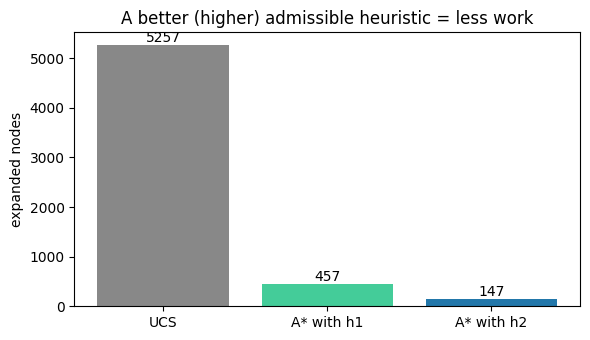

In [10]:
# ---- Experiment: heuristic dominance on the 8-puzzle ----------------------
# We solve the same 8-puzzle with UCS, A*(h1) and A*(h2) and count how many
# nodes each procedure expands. The expectation (dominance):
#   UCS  >=  A*(h1)  >=  A*(h2)      and all find the same optimal length.
results = {}
solved = astar_search(p8, h=p8.h2)[0]
opt_len = solved.path_cost
print(f"Optimal solution length: {opt_len:.0f} moves\n")

for name, algo in [
    ("UCS",         lambda: uniform_cost_search(p8)),
    ("A* with h1",  lambda: astar_search(p8, h=p8.h1)),
    ("A* with h2",  lambda: astar_search(p8, h=p8.h2)),
]:
    node, exp = algo()
    results[name] = exp
    assert node.path_cost == opt_len, "all of them should be optimal!"
    print(f"{name:12s}: {exp:5d} expanded nodes, length {node.path_cost:.0f}")

plt.figure(figsize=(6, 3.5))
plt.bar(results.keys(), results.values(), color=["#888", "#4C9", "#27A"])
plt.ylabel("expanded nodes")
plt.title("A better (higher) admissible heuristic = less work")
for i, v in enumerate(results.values()):
    plt.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout(); plt.show()

## Part D — Final check: optimality

Finally the proof by example: greedy and BFS find a route, but not the
*cheapest* one; UCS and A\* do (418 km). Run the cell — the `assert` confirms
it.

In [11]:
# ---- Self-check: greedy is NOT optimal, A* is ---------------------------
g_node, _ = greedy_search(romania)
a_node, _ = astar_search(romania)
print("Greedy cost:", g_node.path_cost, "->", path_states(g_node))
print("A* cost    :", a_node.path_cost, "->", path_states(a_node))
print()
print("All four procedures compared (Arad->Bucharest):")
for name, fn in [("BFS", breadth_first_search),
                 ("UCS", uniform_cost_search),
                 ("A*",  astar_search),
                 ("IDDFS", lambda p: iterative_deepening_search(p)[:2])]:
    node, exp = fn(romania)
    tag = "optimal" if node.path_cost == 418 else "NOT optimal (only the fewest steps)"
    print(f"  {name:6s} cost={node.path_cost:4.0f} km  ({tag})")
assert a_node.path_cost == 418 and g_node.path_cost >= a_node.path_cost
print("\nAll consistent: A*/UCS optimal (418 km), greedy/BFS not guaranteed.")

Greedy cost: 450.0 -> ['Arad', 'Sibiu', 'Fagaras', 'Bucharest']
A* cost    : 418.0 -> ['Arad', 'Sibiu', 'Rimnicu', 'Pitesti', 'Bucharest']

All four procedures compared (Arad->Bucharest):
  BFS    cost= 450 km  (NOT optimal (only the fewest steps))
  UCS    cost= 418 km  (optimal)
  A*     cost= 418 km  (optimal)
  IDDFS  cost= 450 km  (NOT optimal (only the fewest steps))

All consistent: A*/UCS optimal (418 km), greedy/BFS not guaranteed.


## Reflection (in writing, briefly)

Answer for yourself (bullet points are enough):

1. **Why** is BFS not optimal on the Romania map, but optimal on the 8-puzzle?
   (Keyword: step costs.)
2. A\*($h_2$) expands fewer nodes than A\*($h_1$). Justify that with the
   dominance argument from the script ($h(n) < C^\* - g(n)$).
3. Would $h(n) = 2 \cdot h_2(n)$ still be admissible? What could happen to the
   optimality of A\*? (Hint: overestimation.)
4. IDDFS expands *cumulatively* more nodes than BFS — why does one use it
   anyway? (Keyword: memory.)

Answer these for yourself after you have worked through the project — there are deliberately no reference answers.